In [1]:
import sys
sys.path.insert(0, '../')

import pandas as pd

from automed import *
from IPython.display import display, Markdown as IMarkdown, HTML as IHTML
from rich.console import Console
from rich.markdown import Markdown

[10:27:41] cuDF not found: falling back to standalone pandas.

In [2]:
dataset = pd.read_csv('../perf_logger/tests_data/titanic.csv', delimiter=';').drop(['ind'], axis=1)

In [3]:
autom = AutoMed()

print(autom.default_pipeline())
print(autom.json_pipeline())

None
{'step': 'MetaOrderedStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'MetaStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'ActSplitDate', 'name': 'Transform string column to date', 'description': 'Step description...', 'configuration': {}, 'children': []}, {'step': 'ActDropDateColumn', 'name': 'Drop date columns', 'description': 'Drop date columns.', 'configuration': {}, 'children': []}, {'step': 'ActTfIdf', 'name': 'TF-IDF', 'description': 'Step description...', 'configuration': {}, 'children': []}, {'step': 'ActDropNumericalColumn', 'name': 'Drop numerical columns', 'description': 'Drop numerical columns where the proportion of empty rows\n        in the dataset is higher than {empty_threshold}.', 'configuration': {'empty_threshold': {'description': 'Column with more or equal proportion of empty row                     will dropped. 1 will drop all columns', 'd

In [4]:
pipeline = {
    'step': 'MetaOrderedStep',
    'children': [
        {
            'step': 'MetaStep',
            'tag': 'cleaning',
        },
        {
            'step': 'MetaStep',
            'tag': 'features_selection',
        },
        {
            'step': 'WrapKFold',
            'children': [{
                'step': 'ActKNN',
            }]
        },
    ]
}

autom.load_pipeline(pipeline)
print(autom.json_pipeline())


{'step': 'MetaOrderedStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'MetaStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'ActSplitDate', 'name': 'Transform string column to date', 'description': 'Step description...', 'configuration': {}, 'children': []}, {'step': 'ActDropDateColumn', 'name': 'Drop date columns', 'description': 'Drop date columns.', 'configuration': {}, 'children': []}, {'step': 'ActTfIdf', 'name': 'TF-IDF', 'description': 'Step description...', 'configuration': {}, 'children': []}, {'step': 'ActDropNumericalColumn', 'name': 'Drop numerical columns', 'description': 'Drop numerical columns where the proportion of empty rows\n        in the dataset is higher than {empty_threshold}.', 'configuration': {'empty_threshold': {'description': 'Column with more or equal proportion of empty row                     will dropped. 1 will drop all columns', 'defaul

In [5]:
results = autom.fit(
    dataset.drop('label', axis=1).copy(),
    dataset[['label']]).copy()

Output()

[10:27:42] running step: MetaOrderedStep (steps=WrapKFold,MetaStep)

           running step: MetaStep                                                                                  
           (steps=ActDropDateColumn,ActMeanColumn,ActDropNumericalColumn,ActDropTextualColumn,ActOnehot,ActSplitDat
           e,ActTfIdf)

[10:27:47] running step: MetaStep (steps=ActRemoveHighCorrelatedColumn)

[10:27:57] running step: WrapKFold (step=ActKNN, folds=5, stratify=True)

           running k-folds: ActKNN             (metric=minkowski, n_neighbors=5)

Learn : KNN
[('Fill missing values with mean', <automed.actionables.cleaning.act_mean_column.ActMeanColumn object at 0x0000024EFE68ED90>), ('Transform string column to date', <automed.actionables.cleaning.act_split_date.ActSplitDate object at 0x0000024EFE68EC90>), ('One hot encoding categorical features', <automed.actionables.cleaning.act_onehot.ActOnehot object at 0x0000024EFE68EDD0>), ('TF-IDF', <automed.actionables.cleaning.act_tf_idf.ActTfIdf object at 0x0000024EFE68ECD0>), ('Drop date columns', <automed.actionables.cleaning.act_drop_date_column.ActDropDateColumn object at 0x0000024EFE68ED10>), ('Drop numerical columns', <automed.actionables.cleaning.act_drop_numerical_column.ActDropNumericalColumn object at 0x0000024EFE68ED50>), ('Drop textual columns', <automed.actionables.cleaning.act_drop_textual_column.ActDropTextualColumn object at 0x0000024EFE68EE10>), ('Remove High Correlated Column', <automed.actionables.features_selection.act_remove_high_correlated_column.ActRemoveHighCor


## Fill missing values with mean
**Fills missing values with the mean of non-missing values
        when the proportion of empty rows is lower than 0.5.**


### Configuration
| Name | Description | Value |
| ---- | ----------- | ----- |
| **empty_threshold** | Column with less or equal proportion of empty row will                     be fill with mean value. 1 will always fill void values | 0.5 |
        

### Processings
 - Filled missing values of column **`Age`** with **29.70**
                because **177** out of **891** values
                (**19.87**%) were missing.

        



        


## One hot encoding categorical features
**Step description...**



### Processings
 - Encoded categorical column **`Sex`** into **2** new columns.
 - Encoded categorical column **`Embarked`** into **4** new columns.

        



        


## TF-IDF
**Step description...**



### Processings
 - Encoded text column **`Name`** into **1509** new columns.
 - Encoded text column **`Ticket`** into **695** new columns.
 - Encoded text column **`Cabin`** into **158** new columns.

        



        


## Remove High Correlated Column
**Remove columns which correlation with other columns is higher than 0.9.**


### Configuration
| Name | Description | Value |
| ---- | ----------- | ----- |
| **threshold** | If two columns is correlated over this value, only one                     will be kept | 0.9 |
        

### Processings
 - Dropped column **`Sex_male`** because it was too correlated with
                **`Sex_female`**.
 - Dropped column **`Name_amanda`** because it was too correlated with
                **`Name_adolfina`**.
 - Dropped column **`Name_antino`** because it was too correlated with
                **`Name_aijo`**.
 - Dropped column **`Name_asim`** because it was too correlated with
                **`Name_adola`**.
 - Dropped column **`Name_aurora`** because it was too correlated with
                **`Name_adelia`**.
 - Dropped column **`Name_banoura`** because it was too correlated with
                **`Name_ayoub`**.
 - Dropped column **`Name_barah`** because it was too correlated with
                **`Name_assi`**.
 - Dropped column **`Name_barkworth`** because it was too correlated with
                **`Name_algernon`**.
 - Dropped column **`Name_bazzani`** because it was too correlated with
                **`Name_albina`**.
 - Dropped column **`Name_berthe`** because it was too correlated with
                **`Name_antonine`**.
 - Dropped column **`Name_blyler`** because it was too correlated with
                **`Name_billiard`**.
 - Dropped column **`Name_bratthammer`** because it was too correlated with
                **`Name_bernt`**.
 - Dropped column **`Name_butt`** because it was too correlated with
                **`Name_archibald`**.
 - Dropped column **`Name_cassem`** because it was too correlated with
                **`Name_albimona`**.
 - Dropped column **`Name_cerin`** because it was too correlated with
                **`Name_balkic`**.
 - Dropped column **`Name_chip`** because it was too correlated with
                **`Name_chang`**.
 - Dropped column **`Name_christine`** because it was too correlated with
                **`Name_carla`**.
 - Dropped column **`Name_chronopoulos`** because it was too correlated with
                **`Name_apostolos`**.
 - Dropped column **`Name_clear`** because it was too correlated with
                **`Name_cameron`**.
 - Dropped column **`Name_cornelia`** because it was too correlated with
                **`Name_alma`**.
 - *and **1102** more processings...*
        



        


## K-Fold cross validation
**Performs cross-validation on the dataset, splitting into
        train and test sets 5 times.**


### Configuration
| Name | Description | Value |
| ---- | ----------- | ----- |
| **folds** | Split ratio | 5 |
| **stratify** | Whether to run stratified K-Fold | True |
        

### Processings
 - Computed mean metrics.
 - Trained 5 models, then one last model
                on the whole dataset, and returned it as the output.

        



        


## Learn : KNN
**Step description...**


### Configuration
| Name | Description | Value |
| ---- | ----------- | ----- |
| **metric** | Can be minkowski or manhattan | minkowski |
| **n_neighbors** | Number of neighbors | 5 |
        


### Metrics
| Metric name | Computed value | Description |
| ----------- | -------------- | ----------- |
| `accuracy` | **0.6959** | *Accuracy classification score.* |
| `balanced_accuracy` | **0.6672** | *Compute the balanced accuracy.* |
| `classification_error` | **0.3328** | *Computes the classification error, if accuracy is relevant then the             classification error is calculated by 1 - accuracy otherwise if balanced             accuracy is relevant then the classification error is             calculated by 1 - balanced _accuracy.* |
| `f1_score` | **0.6525** | *Compute the F1 score, also known as balanced F-score or F-measure.             The F1 score can be interpreted as a harmonic mean of the precision and recall* |
| `precision` | **0.6826** | *Compute the precision: The precision is the ratio tp / (tp + fp)             where tp is the number of true positives and fp the number of false positives.* |
| `recall` | **0.6826** | *The recall is the ratio tp / (tp + fn) where tp is the number             of true positives and fn the number of false negatives. The recall is             intuitively the ability of the classifier to find all the positive samples.* |
| `specificity` | **0.7905** | *The proportion of negative instances that are corectely             classified as negative: tn / (tn + fp)* |



        

  0%|          | 0/68 [00:00<?, ?it/s]


## Learn : KNN
**Step description...**


### Configuration
| Name | Description | Value |
| ---- | ----------- | ----- |
| **metric** | Can be minkowski or manhattan | minkowski |
| **n_neighbors** | Number of neighbors | 5 |
        



### Features impact
| Feature | Mean impact (SHAP value) |
| ------- | ------------------------ |
| `Pclass` | **0.006** |
| `Name` | **0.006** |
| `Sex` | **0.042** |
| `Age` | **0.074** |
| `SibSp` | **0.018** |
| `Parch` | **0.009** |
| `Ticket` | **0.002** |
| `Fare` | **0.154** |
| `Cabin` | **0.005** |
| `Embarked` | **0.015** |


### SHAP plots


#### Force plot
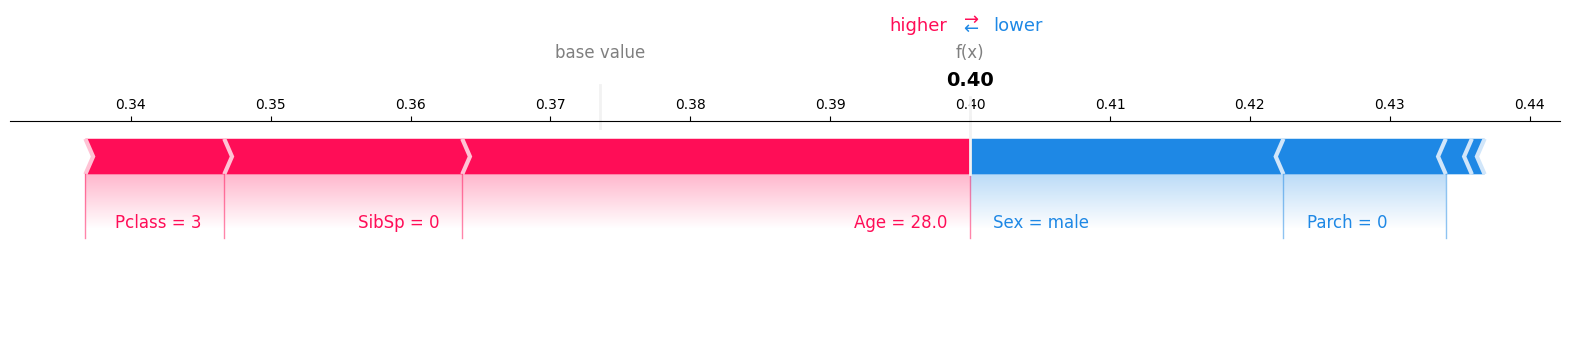

***Reading**: For this prediction, `Age` impacts the final prediction value by **0.036**.*



#### Waterfall plot
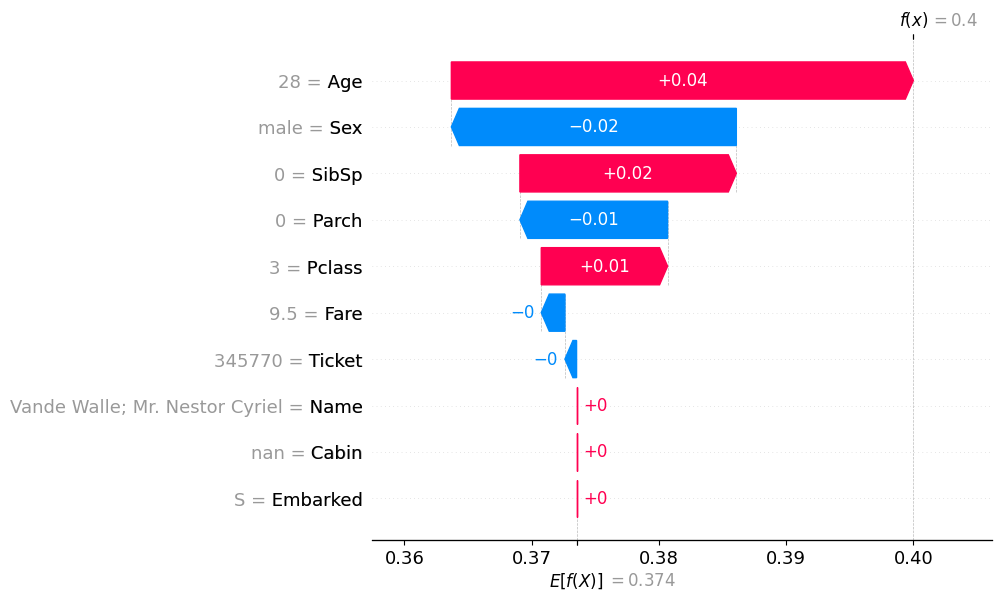

***Reading**: For this prediction, `Age` impacts the final prediction value by **0.036**.*



#### Beeswarm plot
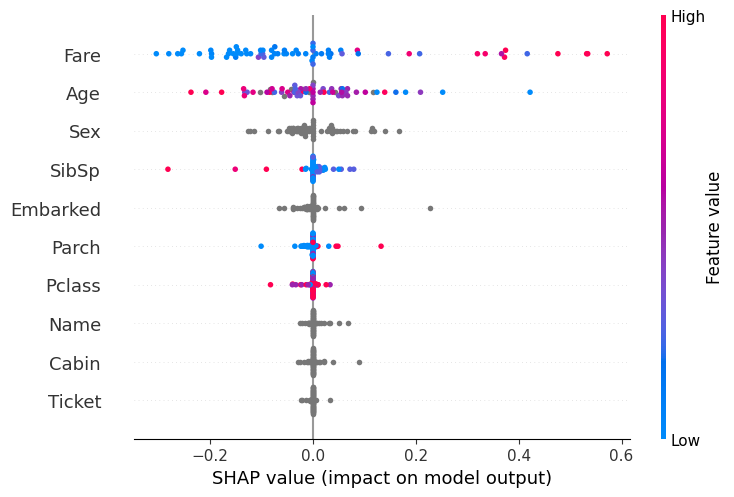



#### Heatmap plot
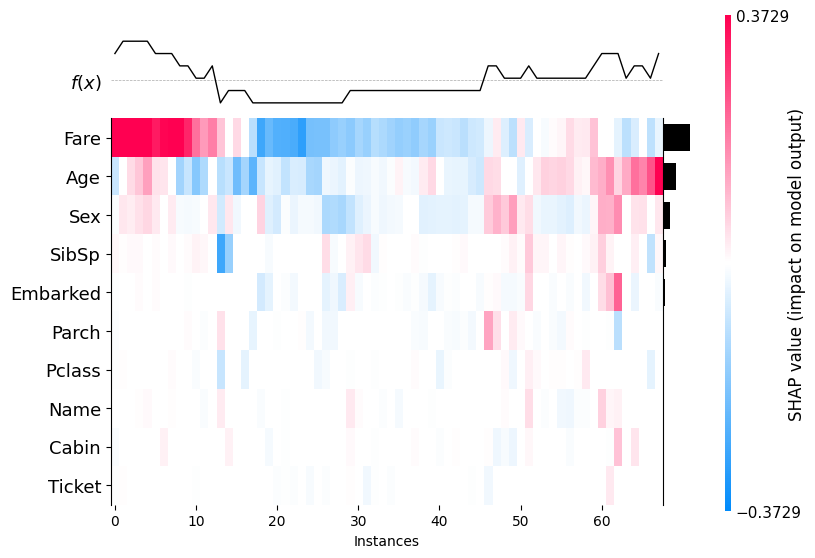



#### Scatter plot
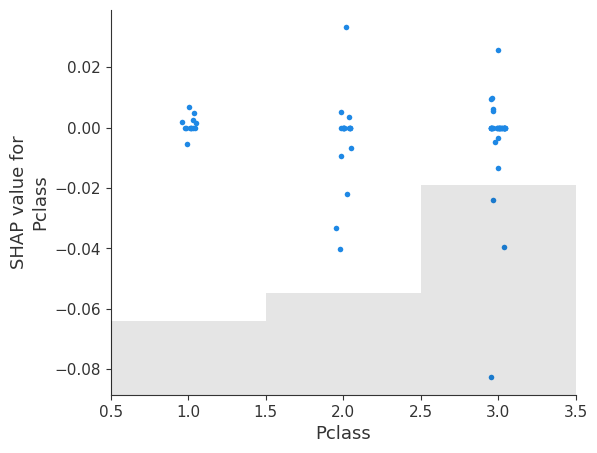



#### Bar plot
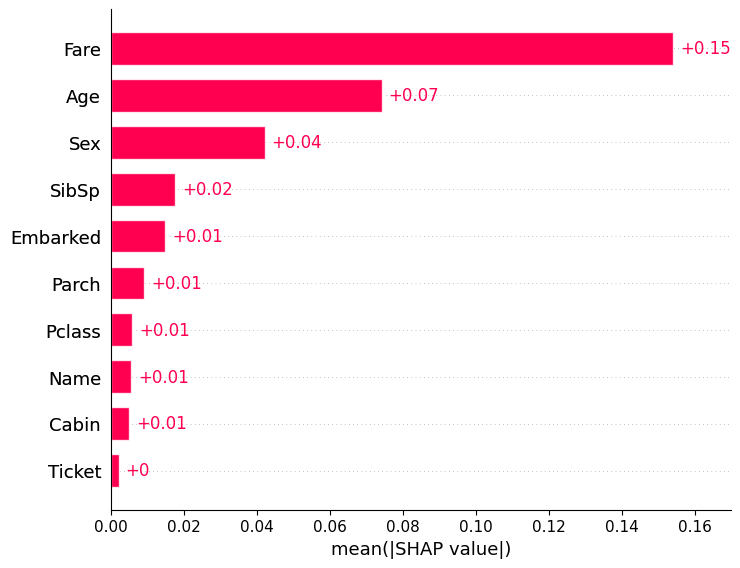

***Reading**: `Fare` has an absolute impact of **0.154** on the average final prediction value.*


        

In [6]:
print(results[0].pipeline.model)
print(results[0].pipeline.steps)

console = Console()

for step in results[0].pipeline.explanations:
    md = step.to_markdown()
    if md:
        # console.print(Markdown(md))
        display(IMarkdown(md))
        pass

test = dataset.iloc[200:(200+68)].drop('label', axis=1).copy()
display(IMarkdown(results[0].explain_model(test, nsamples=50).to_markdown(plots=['force', 'waterfall', 'scatter', 'beeswarm', 'heatmap', 'bar'])))

pm = results[0].pipeline.pickle()

In [ ]:
import pickle

o = 0 # offset
n = 68  # # of samples
labels = dataset.iloc[o:(o+n)]['label']
predict_df = dataset.iloc[o:(o+n)].drop('label', axis=1).copy()

# labels = labels.reset_index()
predict_df.reset_index(inplace=True, drop=True)

m = pickle.loads(pm)
sum([ r == labels.iloc[o+i] for i, r in enumerate(m.predict(predict_df)) ]) / n

0.5882352941176471

In [17]:
final_boss_automed = AutoMed(max_workers=2)
final_boss_automed.default_pipeline()
final_boss_results = final_boss_automed.fit(dataset.drop('label', axis=1).copy(), dataset[['label']].copy())

[10:06:49] running step: MetaOrderedStep (steps=MetaStep,MetaExplorerStep)

           running step: MetaStep                                                                                  
           (steps=ActDropDateColumn,ActDropTextualColumn,ActDropNumericalColumn,ActSplitDate,ActMeanColumn,ActTfIdf
           ,ActOnehot)

[10:06:50] running step: MetaStep (steps=ActRemoveHighCorrelatedColumn)

           running step: MetaStep (steps=ActMinMaxScaler,ActRandomOverSampling)

           running step: MetaExplorerStep (steps=WrapGeneticGridSearch)

...

           running step: WrapKFold (step=ActXGBoost, folds=5, stratify=True)

           running k-folds: ActXGBoost             (max_depth=2, random_state=42, learning_rate=1.7084073865561846,
           n_estimators=157)

           running step: WrapKFold (step=ActXGBoost, folds=5, stratify=True)

           running k-folds: ActXGBoost             (max_depth=6, random_state=42, learning_rate=3.413082851021946, 
           n_estimators=155)

KeyboardInterrupt: 

In [ ]:
# sum([ len(r.model.pickle()) for r in final_boss_results ])
[ (r.model.ml_model, r.evaluate()) for r in final_boss_results if r.model.ml_model is not None ]

NameError: name 'final_boss_results' is not defined